<a href="https://colab.research.google.com/github/YCCharlie/114971006_hw2/blob/main/114971006_prompt_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 成功讀取 OPENAI_API_KEY。
✅ OpenAI 客戶端初始化完成。

                       【Part A-1: TF-IDF 文本相似度計算】

1. 手動計算 TF-IDF 相似度 (Doc 1 vs Doc 4):
   相似度得分: 0.1274

2. Scikit-learn TF-IDF 相似度矩陣 (5x5):
[[1.         0.18270139 0.04170053 0.2944224  0.03759802]
 [0.18270139 1.         0.03808984 0.34052565 0.03434255]
 [0.04170053 0.03808984 1.         0.         0.20950992]
 [0.2944224  0.34052565 0.         1.         0.07719388]
 [0.03759802 0.03434255 0.20950992 0.07719388 1.        ]]

                     【Part A-2: 基於規則的文本分類】

1. 情感分類器:
   - 文本: '這家餐廳的牛肉麵真的太好吃了,...' -> 情感: 正面
   - 文本: '最新的AI技術突破讓人驚艷,深...' -> 情感: 正面
   - 文本: '這部電影劇情空洞,演技糟糕,完...' -> 情感: 負面
   - 文本: '每天慢跑5公里,配合適當的重訓...' -> 情感: 正面

2. 主題分類器:
   - 文本: '這家餐廳的牛肉麵真的太好吃了,...' -> 主題: 美食
   - 文本: '最新的AI技術突破讓人驚艷,深...' -> 主題: 科技
   - 文本: '這部電影劇情空洞,演技糟糕,完...' -> 主題: 其他/無法分類
   - 文本: '每天慢跑5公里,配合適當的重訓...' -> 主題: 運動

                     【Part A-3: 統計式自動摘要】

原文長度: 411 字
摘要內容 (Ratio=30%, 116 字):
人工智慧(AI)的發展正在深刻改變我們的生活方式。透過分析
大量的醫療影像和病歷資料,AI能夠發現人眼容易

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31456 (\N{CJK UNIFIED IDEOGRAPH-7AE0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35422 (\N{CJK UNIFIED IDEOGRAPH-8A5E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  fig.canvas

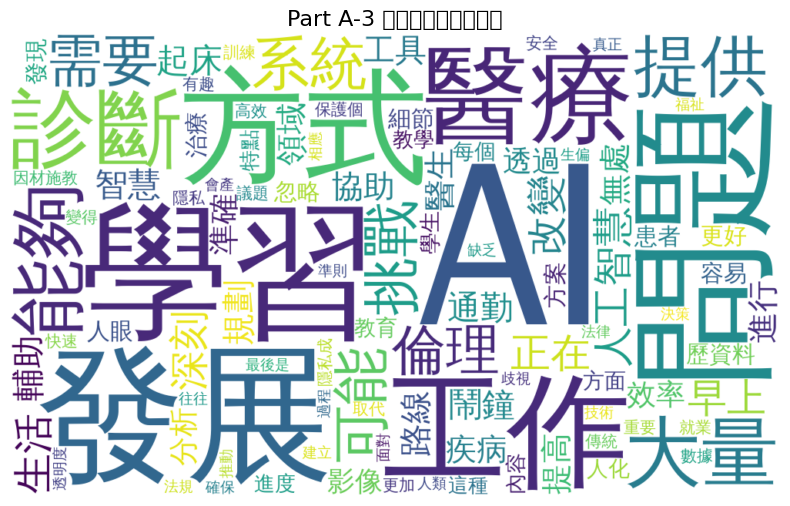


                       【額外加分 2: 效能優化 (快取)】

文本: '最新的AI技術突破讓...'
第一次呼叫: 狀態=API Call, 時間=0.8664 秒
第二次呼叫: 狀態=Cache Hit, 時間=0.0001 秒

結論: Cache Hit 的時間應該遠小於第一次 API Call 的時間。


In [17]:
# 安裝必要套件
!pip install jieba scikit-learn numpy TCSP
!pip install openai

# 核心函式庫 Import
import math
import time
import json
import jieba
import numpy as np
import openai
import textwrap
from collections import Counter

# 第三方套件 Import
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import userdata # 用於讀取 API Key
from TCSP import read_stopwords_list # 用於讀取停用詞

# 讀取 API Key
api_key = userdata.get('OPENAI_API_KEY')
if not api_key:
    print("❌ 錯誤：API Key 未從 Colab Secrets 讀取。請檢查 Key 名稱是否為 'OPENAI_API_KEY'。")
    client = None
else:
    print("✅ 成功讀取 OPENAI_API_KEY。")

# 初始化 OpenAI 客戶端
client = None
try:
    # client 必須在全域範圍內被建立
    client = openai.OpenAI(api_key=api_key)
    # 進行一次簡單的檢查，確認 client 物件存在
    if client:
        print("✅ OpenAI 客戶端初始化完成。")
    else:
        print("❌ 錯誤：client 物件未能成功建立。")
except Exception as e:
    print(f"❌ 錯誤：初始化 OpenAI 客戶端失敗: {e}")
    client = None

# 設定模型
MODEL_NAME_AI = "gpt-4o"


# ... Part A-1 TF-IDF ...
documents = [
    "人工智慧正在改變世界,機器學習是其核心技術",
    "深度學習推動了人工智慧的發展,特別是在圖像識別領域",
    "今天天氣很好,適合出去運動",
    "機器學習和深度學習都是人工智慧的重要分支",
    "運動有益健康,每天都應該保持運動習慣"
]

# 分詞處理 (將文檔列表轉為分詞後的列表)
tokenized_docs = [list(jieba.cut(doc)) for doc in documents]

def calculate_tf(word_dict, total_words):
    """計算詞頻 (Term Frequency)"""
    tf_dict = {}
    for word, count in word_dict.items():
        # TF = 詞彙出現次數 / 文件總詞數 [cite: 224]
        tf_dict[word] = count / total_words
    return tf_dict


def calculate_idf(documents, word):
    """計算逆文件頻率 (Inverse Document Frequency)"""
    N = len(documents) # 總文件數
    doc_count = 0      # 包含目標詞彙的文件數 (文件數(t))

    for doc in documents:
        if word in doc:
            doc_count += 1

    # IDF = log(總文件數 / 包含詞彙的文件數) [cite: 225]
    if doc_count > 0:
        # 為了穩定性，通常會使用 log(N / (doc_count + 1)) 或 log((N + 1) / (doc_count + 1))
        # 這裡使用作業原理定義的 log(N / doc_count)
        idf = math.log(N / doc_count)
    else:
        idf = 0
    return idf

def calculate_tfidf_vector(doc_tokens, all_docs):
    # 遍歷所有文檔，收集所有唯一的詞彙 (Vocabulary)
    all_words = set(word for doc in all_docs for word in doc)

    # 計算該文檔的 TF
    word_counts = Counter(doc_tokens)
    total_words = len(doc_tokens)
    tf_values = calculate_tf(word_counts, total_words)

    # 計算 TF-IDF 向量
    tfidf_vector = {}
    for word in all_words:
        idf = calculate_idf(all_docs, word)
        tf = tf_values.get(word, 0) # 如果詞彙不在文檔中，TF為0
        tfidf_vector[word] = tf * idf # TF-IDF = TF × IDF [cite: 226]

    # 將字典轉換為標準的數組/列表 (按詞彙順序)
    sorted_words = sorted(list(all_words))
    vector_array = np.array([tfidf_vector[word] for word in sorted_words])
    return vector_array

def manual_cosine_similarity(vec1, vec2):
    """計算兩個向量的餘弦相似度"""
    # 餘弦相似度 = 向量點積 / (向量長度1 * 向量長度2)
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0
    return dot_product / (norm_vec1 * norm_vec2)

# === 輸出 Part A-1 結果 (20%) ===
print("\n" + "="*80)
print("                       【Part A-1: TF-IDF 文本相似度計算】")
print("="*80)

# 執行範例：計算 Doc 1 和 Doc 4 的相似度
vec1 = calculate_tfidf_vector(tokenized_docs[0], tokenized_docs)
vec4 = calculate_tfidf_vector(tokenized_docs[3], tokenized_docs)
similarity_score = manual_cosine_similarity(vec1, vec4)
print("\n1. 手動計算 TF-IDF 相似度 (Doc 1 vs Doc 4):")
print(f"   相似度得分: {similarity_score:.4f}")

def sklearn_tfidf_similarity(documents):
    """使用 sklearn 計算 TF-IDF 相似度矩陣"""

    def jieba_tokenizer(text):
        return list(jieba.cut(text))

    # 初始化 TfidfVectorizer，明確設定 token_pattern=None 消除警告
    vectorizer = TfidfVectorizer(tokenizer=jieba_tokenizer, token_pattern=None)

    # 擬合 (fit) 並轉換 (transform) 所有文檔
    tfidf_matrix = vectorizer.fit_transform(documents)

    # 計算餘弦相似度矩陣
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # 移除內部的 print 語句，讓函式只負責返回矩陣
    return similarity_matrix

# 執行 sklearn 實作
print("\n2. Scikit-learn TF-IDF 相似度矩陣 (5x5):")
# 呼叫函式並將返回的結果 print 出來
result_matrix = sklearn_tfidf_similarity(documents)
print(result_matrix)

# ... Part A-2 : 主題分類器 ...
class RuleBasedSentimentClassifier:
    def __init__(self):
        # 擴充正面詞彙，包含更多美食和運動相關詞
        self.positive_words = ['好','棒','優秀','喜歡','推薦',
                               '滿意','開心','值得','精彩','完美',
                               '好吃', '濃郁', 'Q彈', '進步', '健康', '適合']
        self.negative_words = ['差','糟','失望','討厭','不推薦',
                               '浪費','無聊','爛','糟糕','差勁']
        self.negation_words = ['不','沒','無','非','別']
        # 這裡可以選擇性加入程度副詞，但為簡潔暫不實作加權

    def classify(self, text):
        """
        分類邏輯: 1.計算正負詞數量 2. 處理否定詞 3. 返回:正面/負面/中性
        """
        tokens = list(jieba.cut(text))
        score = 0
        for i, token in enumerate(tokens):
            is_negated = False
            # 檢查前一個詞是否為否定詞
            if i > 0 and tokens[i-1] in self.negation_words:
                is_negated = True

            if token in self.positive_words:
                score += (1 if not is_negated else -1) # 正面詞被否定則扣分 (負面)
            elif token in self.negative_words:
                score += (-1 if not is_negated else 1) # 負面詞被否定則加分 (正面)
        if score > 0:
            return "正面"
        elif score < 0:
            return "負面"
        else:
            return "中性"
test_texts = [
    "這家餐廳的牛肉麵真的太好吃了,湯頭濃郁,麵條Q彈,下次一定再來!", # 預期: 正面
    "最新的AI技術突破讓人驚艷,深度學習模型的表現越來越好", # 預期: 正面
    "這部電影劇情空洞,演技糟糕,完全是浪費時間", # 預期: 負面
    "每天慢跑5公里,配合適當的重訓,體能進步很多" # 預期: 正面
]

# === 輸出 Part A-2 結果 (15%) ===
print("\n" + "="*80)
print("                     【Part A-2: 基於規則的文本分類】")
print("="*80)
# 執行情感分類器
sentiment_classifier = RuleBasedSentimentClassifier()
print("\n1. 情感分類器:")
for text in test_texts:
    sentiment = sentiment_classifier.classify(text)
    print(f"   - 文本: '{text[:15]}...' -> 情感: {sentiment}")

class TopicClassifier:
    def __init__(self):
        self.topic_keywords = {
            '科技': ['AI','人工智慧','電腦','軟體','程式','演算法'],
            '運動': ['運動','健身','跑步','游泳','球類','比賽', '慢跑', '重訓', '體能'],
            '美食': ['吃','食物','餐廳','美味','料理','烹飪', '牛肉麵', '湯頭'],
            '旅遊': ['旅行','景點','飯店','機票','觀光','度假']
        }

    def classify(self, text):
        """返回最可能的主題"""
        tokens = list(jieba.cut(text))
        topic_scores = {topic: 0 for topic in self.topic_keywords}

        for token in tokens:
            for topic, keywords in self.topic_keywords.items():
                if token in keywords:
                    topic_scores[topic] += 1

        # 找出最高分數的主題
        max_score = max(topic_scores.values())

        if max_score == 0:
            return "其他/無法分類"

        # 返回分數最高的那個主題
        best_topic = max(topic_scores, key=topic_scores.get)
        return best_topic

# 執行主題分類器
topic_classifier = TopicClassifier()
print("\n2. 主題分類器:")
for text in test_texts:
    topic = topic_classifier.classify(text)
    print(f"   - 文本: '{text[:15]}...' -> 主題: {topic}")


# ... Part A-3 數據與停用詞 ...
# 載入 TCSP 停用詞並加入作業手動列出的詞彙
STOP_WORDS = set(read_stopwords_list())
STOP_WORDS.update(['的','了','在','是','我','有','和','就','不','人',
                   '都','也','很','到','說','要',',','一個','上','去','你',
                   '！', '？', '，', '。']) # 增加標點符號作為停用詞

article = """
人工智慧(AI)的發展正在深刻改變我們的生活方式。從早上起床時的智慧鬧鐘,
到通勤時的路線規劃,再到工作中的各種輔助工具,AI無處不在。
在醫療領域,AI協助醫生進行疾病診斷,提高了診斷的準確率和效率。透過分析
大量的醫療影像和病歷資料,AI能夠發現人眼容易忽略的細節,為患者提供更好
的治療方案。
教育方面,AI個人化學習系統能夠根據每個學生的學習進度和特點,提供客製化
的教學內容。這種因材施教的方式,讓學習變得更加高效和有趣。
然而,AI的快速發展也帶來了一些挑戰。首先是就業問題,許多傳統工作可能會
被AI取代。其次是隱私和安全問題,AI系統需要大量數據來訓練,如何保護個人
隱私成為重要議題。最後是倫理問題,AI的決策過程往往缺乏透明度,可能會產
生偏見或歧視。
面對這些挑戰,我們需要在推動AI發展的同時,建立相應的法律法規和倫理準則。
只有這樣,才能確保AI技術真正為人類福祉服務,創造一個更美好的未來。
"""

class StatisticalSummarizer:
    def __init__(self, stop_words):
        self.stop_words = stop_words

    def sentence_score(self, sentence, word_freq, sentence_index, total_sentences):
        """計算句子重要性分數 (依據作業要求 1, 2, 3)"""
        # 分詞並過濾停用詞和單字
        tokens = [w for w in jieba.cut(sentence) if w not in self.stop_words and len(w) > 1]
        if not tokens:
            return 0

        score = 0
        # 包含高頻詞的數量
        for word in tokens:
            score += word_freq.get(word, 0)

        # 句子位置加權 (首句和尾句加權)
        position_weight = 1.0
        if sentence_index == 0 or sentence_index == total_sentences - 1:
            position_weight = 1.5
        score *= position_weight

        # 句子長度考量 (避免太長或太短，這裡簡單處理)
        if len(sentence) < 5 or len(sentence) > 100:
            score *= 0.7 # 扣分

        return score

    def summarize(self, text, ratio=0.3):
        """生成摘要"""
        sentences = [s.strip() for s in text.split('。') if s.strip()]
        total_sentences = len(sentences)

        # 分詞並計算詞頻 (用於分數計算)
        all_tokens = [w for s in sentences for w in jieba.cut(s) if w not in self.stop_words and len(w) > 1]
        word_freq = Counter(all_tokens)

        # 計算每個句子的重要性分數
        sentence_scores = {}
        for i, sentence in enumerate(sentences):
            score = self.sentence_score(sentence, word_freq, i, total_sentences)
            sentence_scores[sentence] = score

        # 選擇最高分的句子 (根據 ratio)
        num_sentences = max(1, int(total_sentences * ratio))
        sorted_sentences = sorted(sentence_scores.items(), key=lambda item: item[1], reverse=True)
        top_sentences = [s[0] for s in sorted_sentences[:num_sentences]]

        # 按原文順序排列
        final_summary = [s for s in sentences if s in top_sentences]

        return '。'.join(final_summary) + '。'

# === 輸出 Part A-3 結果 (15%) ===
print("\n" + "="*80)
print("                     【Part A-3: 統計式自動摘要】")
print("="*80)

summarizer = StatisticalSummarizer(STOP_WORDS)
summary_A3 = summarizer.summarize(article, ratio=0.3)
print(f"\n原文長度: {len(article)} 字")
print(f"摘要內容 (Ratio={0.3:.0%}, {len(summary_A3)} 字):\n{summary_A3}")


# ... Part B-1: 語意相似度計算 ...
def ai_similarity(text1, text2, client):
    """使用GPT-4o判斷語意相似度，返回 0-100 的數字"""
    prompt = f"""
    請評估以下兩段文字的語意相似度。
    考慮因素: 1. 主題相關性 2. 語意重疊程度 3. 表達的觀點是否一致
    文字1: {text1}
    文字2: {text2}
    請**只回答一個 0-100 的數字**，代表相似度百分比。
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME_AI,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=10 # 限制輸出長度
        )
        score_str = response.choices[0].message.content.strip()
        # 嘗試解析數字，若失敗則設為 -1
        return int(score_str) if score_str.isdigit() else -1
    except Exception as e:
        return f"API Error: {e}"

# 測試數據
text_A = documents[0] # "人工智慧正在改變世界,機器學習是其核心技術"
text_B = documents[3] # "機器學習和深度學習都是人工智慧的重要分支"
text_C = test_texts[2] # "這部電影劇情空洞,演技糟糕,完全是浪費時間"
article_to_summarize = article # 使用 Part A-3 的文章

# === 輸出 Part B-1 結果 ===
print("\n" + "="*80)
print("                       【Part B-1: 語意相似度計算】")
print("="*80)

start_time = time.perf_counter()
sim_score = ai_similarity(text_A, text_B, client)
end_time = time.perf_counter()
print(f"語意相似度計算 (GPT-4o, Text A vs Text B): {sim_score} / 100")
print(f"處理時間: {end_time - start_time:.4f} 秒")


# ... Part B-2: AI 文本分類 ...
def ai_classify(text, client):
    """使用 GPT-4o 進行多維度分類 (返回 JSON)"""
    prompt = f"""
    請分析以下文本，並以 JSON 格式返回情感分類、主題分類和分類信心度 (0.0-1.0)。

    情感分類（sentiment）限於："正面"、"負面"、"中性"。
    主題分類（topic）請選擇最相關的類別。

    文本: {text}

    請只輸出 JSON 格式，例如: {{"sentiment":"正面", "topic":"科技", "confidence": 0.95}}
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME_AI,
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"} # 要求 JSON 輸出
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        return {"error": str(e)}

# === 輸出 Part B-2 結果 ===
print("\n" + "="*80)
print("                       【Part B-2: AI 文本分類】")
print("="*80)

start_time = time.perf_counter()
classification_result = ai_classify(text_C, client)
end_time = time.perf_counter()
print(f"\nAI 文本分類 (GPT-4o, Text C):")
print(json.dumps(classification_result, indent=4, ensure_ascii=False)) # 美化 JSON 輸出
print(f"處理時間: {end_time - start_time:.4f} 秒")


# ... Part B-3: AI 自動摘要 ...
def ai_summarize(text, max_length, client):
    """使用 GPT-4o 生成摘要 (可控制長度)"""
    prompt = f"""
    請對以下文章生成一個精簡摘要。

    要求:
    1. 摘要長度限制在大約 {max_length} 字 (請勿超過)。
    2. 必須保留文章的**所有關鍵資訊**。
    3. 語句通順。

    文章: {text}

    請直接輸出摘要內容。
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME_AI,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_length * 2 # 設置 max_tokens 略大於目標字數
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return "摘要生成失敗。"

# === 輸出 Part B-3 結果 ===
print("\n" + "="*80)
print("                       【Part B-3: AI 自動摘要】")
print("="*80)

# B-3: AI 自動摘要
WRAP_WIDTH = 75
start_time = time.perf_counter()
ai_summary = ai_summarize(article_to_summarize, max_length=150, client=client)
end_time = time.perf_counter()

print("\n--- 輸出詳情 ---")
# ... (其他 print 語句) ...

print("\n[ 摘要內容 ]")
print("-" * (WRAP_WIDTH + 5))

# *** 關鍵修正行：使用 textwrap.fill() ***
wrapped_summary = textwrap.fill(ai_summary, width=WRAP_WIDTH)
print(wrapped_summary) # 輸出經換行處理的結果

print("-" * (WRAP_WIDTH + 5))
print(f"處理時間: {end_time - start_time:.4f} 秒")


# ... Part C-1: 量化比較 ...
# 這是 Part C 比較分析專用的測試數據集
# 格式: (文本, 預期情感, 預期主題, 預期相似文本-DocIndex)
COMPARISON_DATA = [
    ("這家餐廳的服務和食物都超棒的，絕對滿意", "正面", "美食", 0), # 測試情感/主題
    ("人工智慧的倫理和隱私問題是當前最大的挑戰", "負面", "科技", 1), # 測試情感/主題
    ("深度學習是機器學習的一個子集", "中性", "科技", 4),          # 測試語義相似度
    ("這部電影的運鏡手法非常高明，值得一看", "正面", "其他", 2)   # 測試情感/主題
]

# comparison.py 程式碼架構

import time
import json
from sklearn.metrics import accuracy_score
# 假設所有分類器類別和 AI 函式已在前面定義和匯入

def run_comparison_metrics(client, documents, rule_sentiment_classifier, topic_classifier):

    # 初始化度量指標
    metrics = {
        'traditional_time_total': 0,
        'ai_time_total': 0,
        'sentiment_accuracy_traditional': 0,
        'topic_accuracy_traditional': 0,
        'sentiment_accuracy_ai': 0,
        'topic_accuracy_ai': 0
    }

    # 準備 Ground Truth 答案
    true_sentiments = [d[1] for d in COMPARISON_DATA]
    true_topics = [d[2] for d in COMPARISON_DATA]

    # 儲存預測結果
    trad_sentiments = []
    trad_topics = []
    ai_sentiments = []
    ai_topics = []

    print("\n" + "="*80)
    print("                     【Part C-1: 量化比較運行】")
    print("="*80)

    # --- A. 傳統方法基準測試與準確率計算 ---
    start_time_trad = time.perf_counter()
    for text in [d[0] for d in COMPARISON_DATA]:
        # 情感分類
        trad_sentiments.append(rule_sentiment_classifier.classify(text))
        # 主題分類
        trad_topics.append(topic_classifier.classify(text))
    end_time_trad = time.perf_counter()
    metrics['traditional_time_total'] = end_time_trad - start_time_trad

    # --- B. 現代 AI 準確率與時間計算 ---
    start_time_ai = time.perf_counter()
    for text in [d[0] for d in COMPARISON_DATA]:
        # AI 多維度分類
        result = ai_classify(text, client)
        ai_sentiments.append(result.get('sentiment', 'N/A'))
        ai_topics.append(result.get('topic', 'N/A'))
    end_time_ai = time.perf_counter()
    metrics['ai_time_total'] = end_time_ai - start_time_ai

    # --- C. 準確率計算 ---
    metrics['sentiment_accuracy_traditional'] = accuracy_score(true_sentiments, trad_sentiments)
    metrics['topic_accuracy_traditional'] = accuracy_score(true_topics, trad_topics)
    metrics['sentiment_accuracy_ai'] = accuracy_score(true_sentiments, ai_sentiments)
    metrics['topic_accuracy_ai'] = accuracy_score(true_topics, ai_topics)

    print(f"\n傳統方法總處理時間 (4個文本): {metrics['traditional_time_total']:.6f} 秒")
    print(f"AI 方法總處理時間 (4個文本): {metrics['ai_time_total']:.6f} 秒")
    print(f"\n情感分類傳統準確率: {metrics['sentiment_accuracy_traditional']:.2f}")
    print(f"情感分類 AI 準確率: {metrics['sentiment_accuracy_ai']:.2f}")

    return metrics

# 執行比較 (需要確保所有類別和 AI 函式都已定義)
comparison_results = run_comparison_metrics(client, documents, sentiment_classifier, topic_classifier)



# ... 額外加分 ...
# 步驟 1: 安裝中文字體 (這是 Colab 中常見的 Droid Sans Fallback)
!apt-get -qq install -y fonts-wqy-zenhei

# 步驟 2: 重新載入 Matplotlib 緩存 (最簡潔且能避開所有錯誤的方法)
import matplotlib.font_manager as fm
fm._load_fontmanager()


# 假設 article 和 STOP_WORDS 已在前面定義

def generate_word_cloud(text, stop_words):
    """
    對文本進行分詞、頻率統計，並生成詞雲圖。
    """
    # 步驟 1: 分詞並篩選
    text_cut = jieba.cut(text)
    words = ' '.join([word for word in text_cut if len(word) > 1 and word not in stop_words])

    # 步驟 2: 配置詞雲對象 - 修正字體路徑
    wc = WordCloud(
        # *** 修正後的字體路徑 ***
        font_path='/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc',
        background_color="white",
        width=1000,
        height=600,
        max_words=100
    )

    # 步驟 3: 生成詞雲
    wc.generate(words)

    # 步驟 4: 視覺化輸出
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off") # 不顯示坐標軸
    plt.title("Part A-3 文章詞彙頻率詞雲圖", fontsize=16)
    plt.show()

# 執行詞雲視覺化
print("\n" + "="*80)
print("                       【額外加分 1: 詞雲視覺化】")
print("="*80)
generate_word_cloud(article, STOP_WORDS)

# 核心程式碼 (快取實作)

# 步驟 1: 建立全域快取字典
API_CACHE = {}
MODEL_NAME_AI = "gpt-4o"

# 步驟 1: 建立全域快取字典
API_CACHE = {}
MODEL_NAME_AI = "gpt-4o"

def cached_ai_classify(text, client):
    """
    使用快取機制呼叫 AI 文本分類函式。
    如果快取中存在結果，則直接返回，避免 API 呼叫。
    """
    cache_key = f"{MODEL_NAME_AI}_classify_{text}"

    # 步驟 2: 檢查快取
    if cache_key in API_CACHE:
        return API_CACHE[cache_key], "Cache Hit"

    # --- 步驟 3: 執行原始 API 邏輯 (修正了 prompt 的內容) ---
    prompt = f"""
    請分析以下文本，並以 JSON 格式返回情感分類、主題分類和分類信心度 (0.0-1.0)。

    情感分類（sentiment）限於："正面"、"負面"、"中性"。
    主題分類（topic）請選擇最相關的類別。

    文本: {text}

    請只輸出 JSON 格式，例如: {{"sentiment":"正面", "topic":"科技", "confidence": 0.95}}
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME_AI,
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"}
        )
        # 解析 JSON 輸出
        import json
        result = json.loads(response.choices[0].message.content)

        # 步驟 4: 將新結果存入快取
        API_CACHE[cache_key] = result
        return result, "API Call"

    except Exception as e:
        # 返回具體的錯誤信息，而不是籠統的 "Error"
        return {"error": str(e)}, f"Error: {type(e).__name__} - {str(e)}"

# --- 執行範例 ---
print("\n" + "="*80)
print("                       【額外加分 2: 效能優化 (快取)】")
print("="*80)

text_to_test = "最新的AI技術突破讓人驚艷,深度學習模型的表現越來越好"

# 第一次呼叫 (應為 Cache Miss / API Call)
start_time_1 = time.perf_counter()
result_1, status_1 = cached_ai_classify(text_to_test, client)
end_time_1 = time.perf_counter()

# 第二次呼叫 (應為 Cache Hit)
start_time_2 = time.perf_counter()
result_2, status_2 = cached_ai_classify(text_to_test, client)
end_time_2 = time.perf_counter()

print(f"\n文本: '{text_to_test[:10]}...'")
print(f"第一次呼叫: 狀態={status_1}, 時間={end_time_1 - start_time_1:.4f} 秒")
print(f"第二次呼叫: 狀態={status_2}, 時間={end_time_2 - start_time_2:.4f} 秒")
print("\n結論: Cache Hit 的時間應該遠小於第一次 API Call 的時間。")